In [1]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from multiprocessing import Pool, cpu_count

##### Load all images and convert to RGBA

In [2]:
def load_all_images(folder_path):
    folder = Path(folder_path)
    images = []

    for item in folder.iterdir():
        if item.is_file():  # makes sure we dont also take folders
            img = cv2.imread(str(item), cv2.IMREAD_UNCHANGED)   # load with alpha preserved
            if img is not None:   # if opencv cannot decode it, img will be None
                images.append(img)

    return images

images = load_all_images("images")

##### plot the actual image on the graph with pixel grid

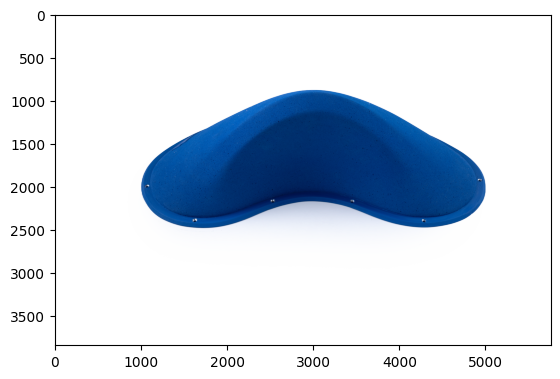

In [3]:
rgba = cv2.cvtColor(images[0], cv2.COLOR_BGRA2RGBA)
plt.imshow(rgba)
plt.show()

##### Plot all the images overlayed on the same graph

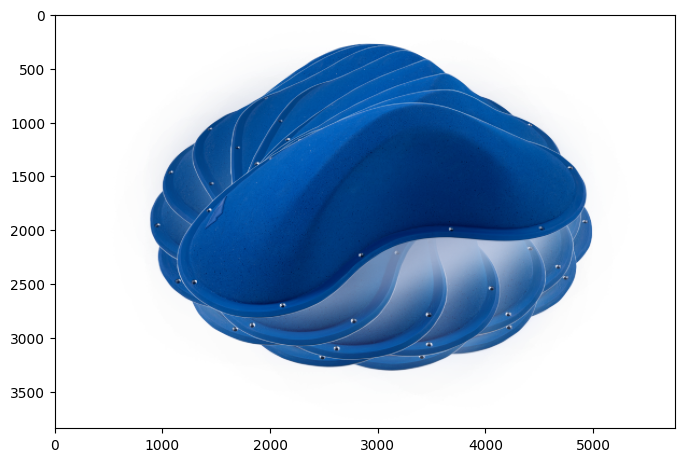

In [4]:
def overlay_images(images, shrink=2):
    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    # Get original full resolution (assume all images same size)
    orig_h, orig_w = images[0].shape[:2]

    for img in images:
        # Resize for speed
        h, w = img.shape[:2]
        small_img = cv2.resize(img, (w // shrink, h // shrink),
                               interpolation=cv2.INTER_AREA)

        # Convert BGR/BGRA -> RGB/RGBA for matplotlib
        if small_img.shape[2] == 4:
            small_img = cv2.cvtColor(small_img, cv2.COLOR_BGRA2RGBA)
        else:
            small_img = cv2.cvtColor(small_img, cv2.COLOR_BGR2RGB)

        # ➤ Plot shrunken image but tell matplotlib its REAL size
        ax.imshow(
            small_img,
            alpha=1,
            extent=[0, orig_w, orig_h, 0]  # left, right, bottom, top
        )

    # Keep original axes ticks
    ax.set_xlim(0, orig_w)
    ax.set_ylim(orig_h, 0)

    plt.show()
overlay_images(images, shrink = 10)

In [5]:
def find_alpha_bounds(images, threshold):
    """
    Combine alphas from all images and detect the bounds where alpha exceeds threshold.
    Returns: left, right, top, bottom
    """

    # 1) Assume all images have same size
    h, w = images[0].shape[:2]

    # 2) Create an empty accumulator mask
    combined_alpha = np.zeros((h, w), dtype=np.uint8)

    # 3) Combine alpha channels from all frames (max = union of all images)
    for img in images:
        alpha = img[:, :, 3]   # take 4th channel
        combined_alpha = np.maximum(combined_alpha, alpha)

    # 4) Apply threshold
    # Anything above threshold becomes "object"
    mask = combined_alpha > threshold

    # 5) If mask is empty (nothing above threshold)
    if not np.any(mask):
        return None, None, None, None

    # 6) Find bounds
    # np.where(mask) gives (rows, cols)
    rows, cols = np.where(mask)

    left   = cols.min()   # first pixel from left
    right  = cols.max()   # first pixel from right
    top    = rows.min()   # first pixel from top
    bottom = rows.max()   # first pixel from bottom

    return left, right, top, bottom
find_alpha_bounds(images, 2)

(636, 5251, 202, 3704)

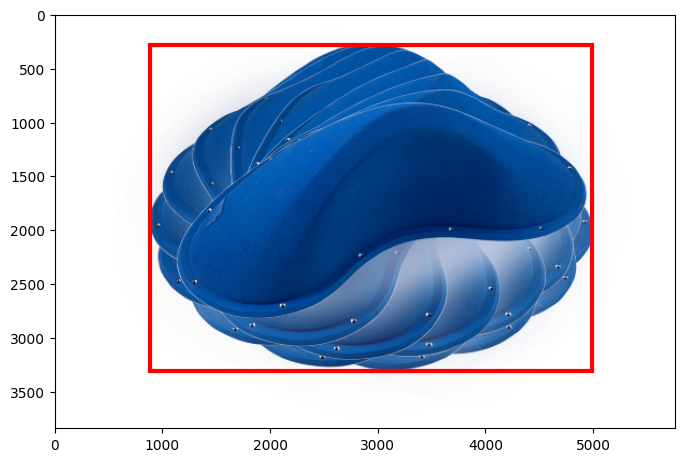

In [6]:
def overlay_images_with_box(images, box, shrink=2):
    left, right, top, bottom = box

    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    orig_h, orig_w = images[0].shape[:2]

    for img in images:
        # shrink for speed
        h, w = img.shape[:2]
        small = cv2.resize(img, (w//shrink, h//shrink), interpolation=cv2.INTER_AREA)

        # convert for matplotlib
        if small.shape[2] == 4:
            small = cv2.cvtColor(small, cv2.COLOR_BGRA2RGBA)
        else:
            small = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)

        # plot shrunken image but scaled to real size
        ax.imshow(small,
                  extent=[0, orig_w, orig_h, 0],
                  alpha=1)

    # ---- DRAW RECTANGLE OVER EVERYTHING ----
    width  = right - left
    height = bottom - top

    rect = patches.Rectangle(
        (left, top),         # (x, y)
        width,               # width
        height,              # height
        linewidth=3,
        edgecolor='red',
        facecolor='none'     # no fill
    )

    ax.add_patch(rect)

    ax.set_xlim(0, orig_w)
    ax.set_ylim(orig_h, 0)

    plt.show()
    

# 1) Compute bounding box based on alpha threshold
left, right, top, bottom = find_alpha_bounds(images, threshold = 100)

# 2) Draw the rectangle on the overlaid images
overlay_images_with_box(
    images,
    (left, right, top, bottom),  # pass as a tuple
    shrink=10                    # shrink the display for speed
)

In [7]:
def crop_images_aspect_ratio(
        images,
        global_box,
        aspect_w=1, aspect_h=1,
        margin_percent=0.20,
        output_folder="cropped"
):

    output = Path(output_folder)
    output.mkdir(exist_ok=True)

    left, right, top, bottom = global_box

    # Rectangle size
    rect_w = right - left
    rect_h = bottom - top

    # Desired aspect ratio
    AR = aspect_w / aspect_h 

    # Use dominant dimension once
    base = rect_w if rect_w >= rect_h else rect_h
    margin = int(base * margin_percent)

    # ASPECT-RATIO ADJUSTED FINAL SIZE
    if rect_w / rect_h > AR:           # too wide
        crop_w = rect_w + 2 * margin
        crop_h = int(crop_w / AR)
    else:                              # too tall
        crop_h = rect_h + 2 * margin
        crop_w = int(crop_h * AR)

    # Crop center (global)
    cx = (left + right) // 2
    cy = (top + bottom) // 2

    # Precompute once
    half_w = crop_w // 2
    half_h = crop_h // 2

    crop_left   = cx - half_w
    crop_right  = cx + half_w
    crop_top    = cy - half_h
    crop_bottom = cy + half_h

    # Preallocate white background for speed
    white_bg = np.ones((crop_h, crop_w, 3), dtype=np.uint8) * 255

    # We reuse a single canvas buffer to avoid re-allocating
    canvas = np.ones((crop_h, crop_w, 4), dtype=np.uint8) * 255

    for i, img in enumerate(images):
        h, w = img.shape[:2]

        # CLEAR the canvas in-place instead of recreating it
        canvas[:, :, :] = 255

        # Source crop region (only computed once)
        src_x1 = max(0, crop_left)
        src_y1 = max(0, crop_top)
        src_x2 = min(w, crop_right)
        src_y2 = min(h, crop_bottom)

        # Destination inside canvas
        dst_x1 = src_x1 - crop_left
        dst_y1 = src_y1 - crop_top
        dst_x2 = dst_x1 + (src_x2 - src_x1)
        dst_y2 = dst_y1 + (src_y2 - src_y1)

        # Paste image region directly
        canvas[dst_y1:dst_y2, dst_x1:dst_x2] = img[src_y1:src_y2, src_x1:src_x2]

        # ALPHA COMPOSITE (fast version)
        alpha = canvas[:, :, 3]  # shape (H, W)
        inv_alpha = 255 - alpha  # also uint8

        # Fast per-pixel blend without python loops
        result = ((canvas[:, :, :3] * (alpha[..., None] / 255.0)) +
                  (white_bg * (inv_alpha[..., None] / 255.0))).astype(np.uint8)

        # save
        cv2.imwrite(str(output / f"frame_{i+1:02d}.png"), result)   # i+1 starts from _01.png

    print(f"Saved {len(images)} processed frames to '{output_folder}'")


In [8]:
global_box = find_alpha_bounds(images, threshold=100)

crop_images_aspect_ratio(
    images,
    global_box,
    aspect_w=4,
    aspect_h=3,
    margin_percent=0.05,
    output_folder="cropped"
)

Saved 16 processed frames to 'cropped'
